In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [12]:
# Load the data to examine its structure
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnet50_UH_stage1_results.csv'

df = pd.read_csv(file_path)
df['per_class_accuracy'] = df['per_class_accuracy']/100
# Display the first few rows of the dataframe to understand its structure
df.head()

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history
0,resnet50-UH-sgd-step-cross_entropy_loss,CrossEntropyLoss(),sgd,step,0.00001,512,0.342605,0.000068,4098.555392,5696.892255,"{'train_loss': [1.2095082133100303, 0.81654498..."
1,resnet50-UH-sgd-step-label_smoothing_loss,label_smoothing,sgd,step,0.00001,512,0.788267,0.003030,4098.555392,5815.881567,"{'train_loss': [1.846613117546744, 1.534074588..."
2,resnet50-UH-sgd-cos-cross_entropy_loss,CrossEntropyLoss(),sgd,cos,0.00000,512,0.176829,0.000068,4098.555392,5668.016690,"{'train_loss': [1.212372740535697, 0.819945579..."
3,resnet50-UH-sgd-cos-label_smoothing_loss,label_smoothing,sgd,cos,0.00000,512,0.777394,0.003160,4098.555392,5769.205127,"{'train_loss': [1.8459989348621408, 1.53064200..."
4,resnet50-UH-sgd-ReduceLROnPlateau-cross_entrop...,CrossEntropyLoss(),sgd,ReduceLROnPlateau,0.01000,512,0.740388,0.003001,4098.555392,5662.855814,"{'train_loss': [1.2103412683133863, 0.82276835..."


# Training Plots By Optimizer

In [13]:
# for each model, plot the training an validation curves
history = df['history'][0]
model_name = df['model_name'][0]
history = history.replace("\'", "\"")
# load json object
history = json.loads(history)

In [14]:
# select only rows where optimizer == sgd
df_sgd = df[df['optimizer'] == 'sgd']
for row in df_sgd.iterrows():
  history = row[1]['history']
  model_name = row[1]['model_name']
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

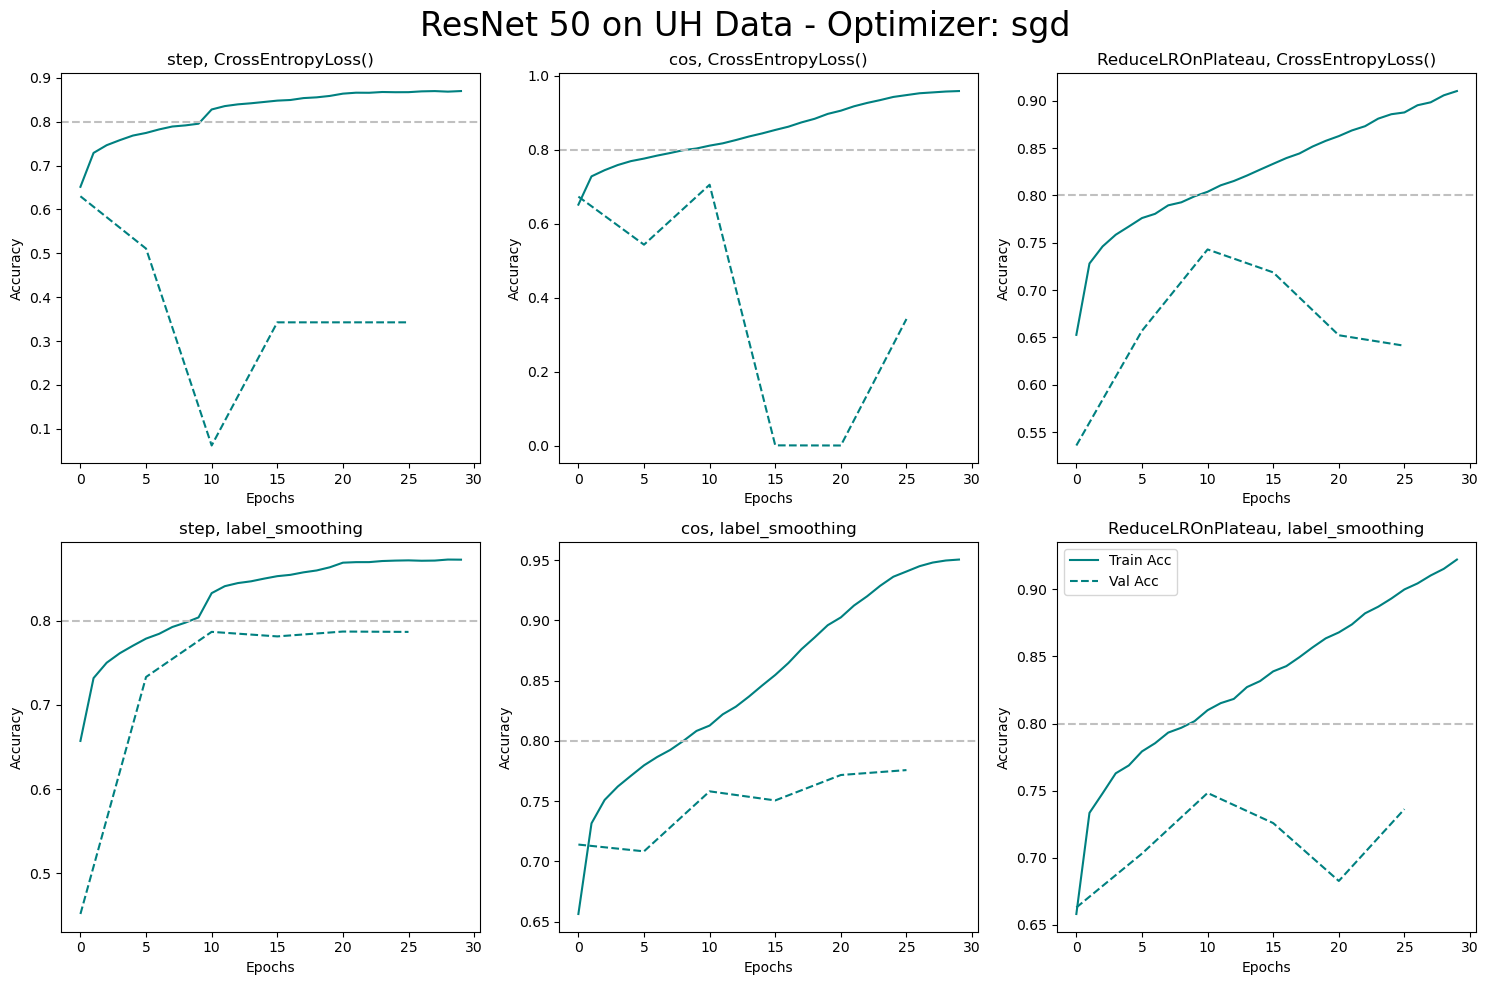

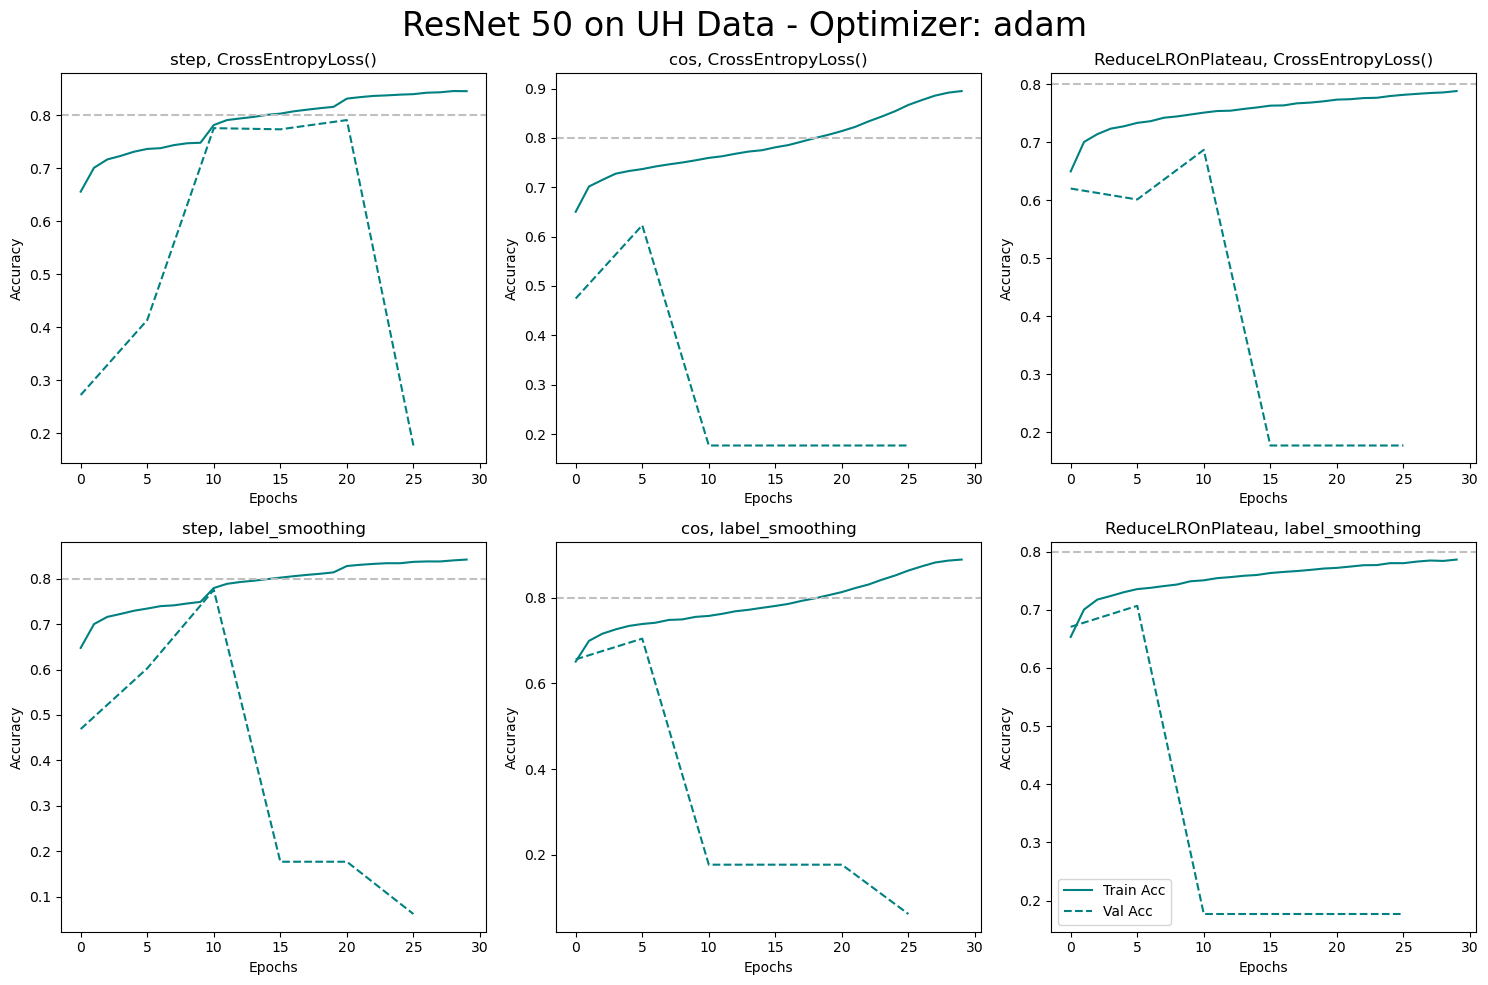

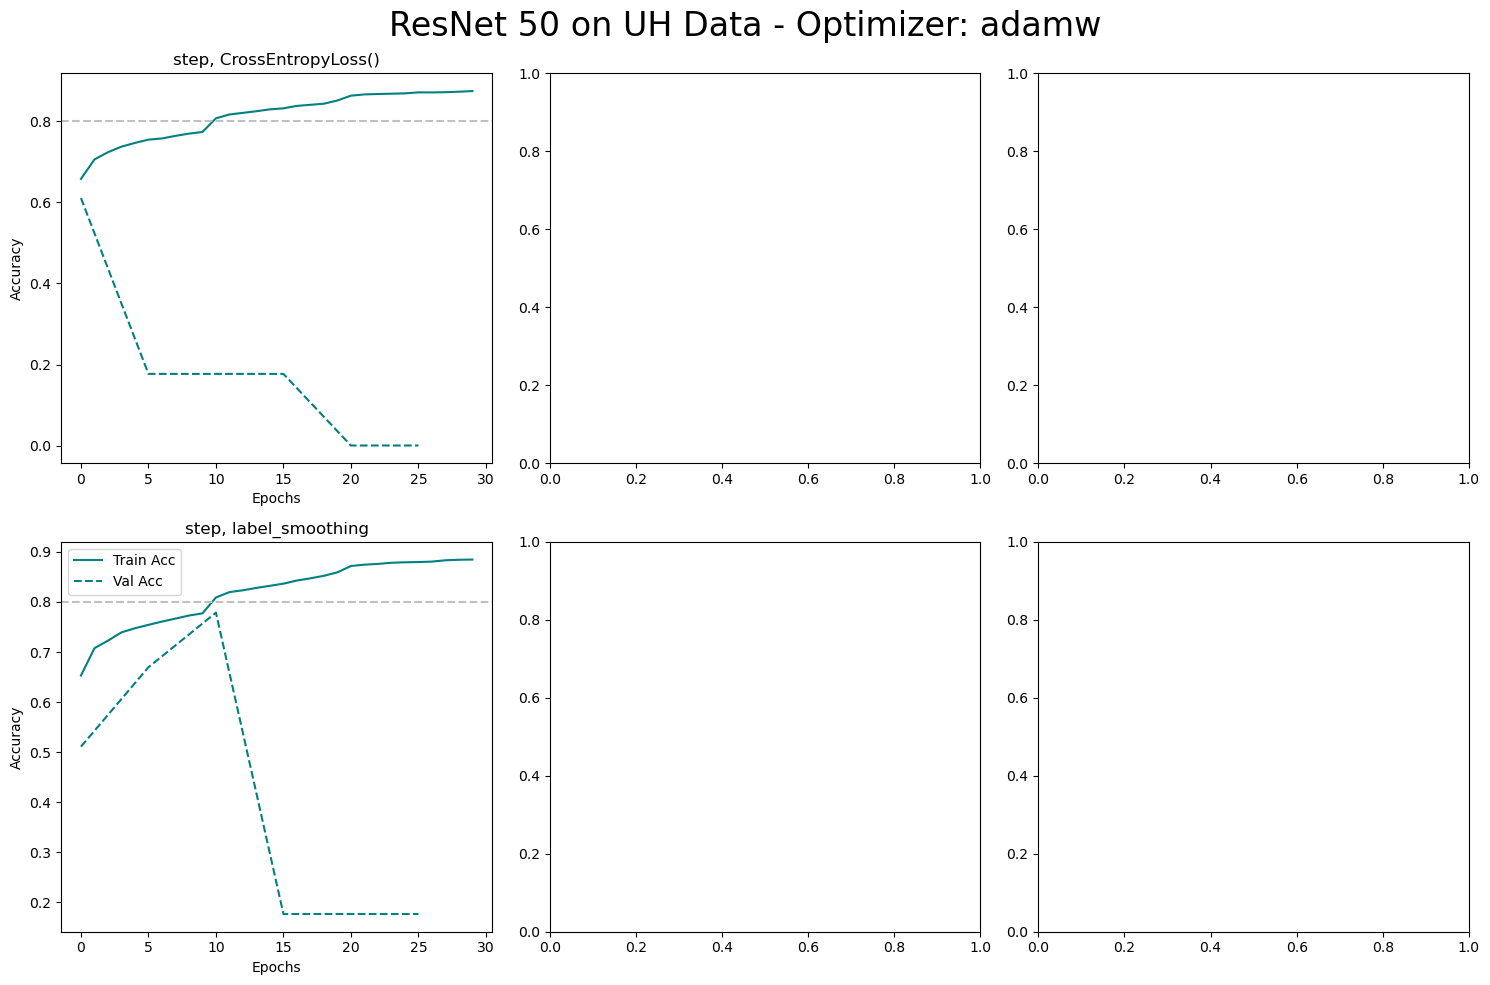

In [15]:
for opt in df['optimizer'].unique():
  df_sgd = df[df['optimizer'] == opt]
  fig, axes = plt.subplots(2,3, figsize=(15,10))
  for ax, row in zip(axes.flatten(order='F'), df_sgd.iterrows()):
    history = row[1]['history']
    model_name = f"{row[1]['scheduler']}, {row[1]['loss_function']}"
    history = history.replace("\'", "\"")
    history = json.loads(history)
    ax.set_title(model_name, fontdict={"fontsize":12})
    ax.plot(history['train_acc'], label='Train Acc', color='teal')
    ax.plot(history['val_epochs'], history['val_acc'], label='Val Acc', color='teal', ls='--')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    # horizontal dashed line at .80
    ax.axhline(y=.80, color='silver', linestyle='--')
  ax.legend()
  plt.suptitle(f"ResNet 50 on UH Data - Optimizer: {opt}", size=24)

  plt.tight_layout()
  plt.show()

## Individual Plots 

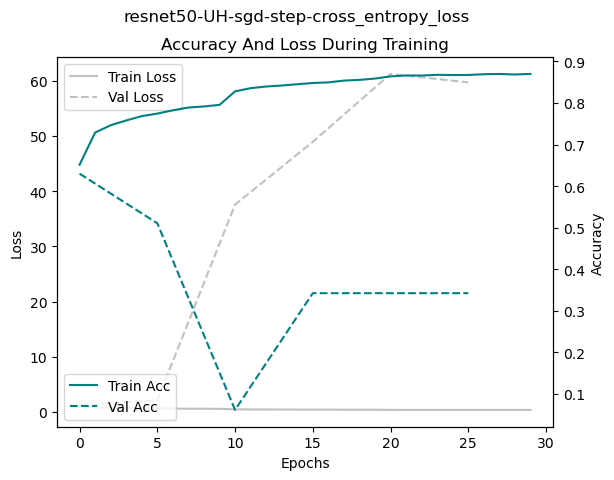

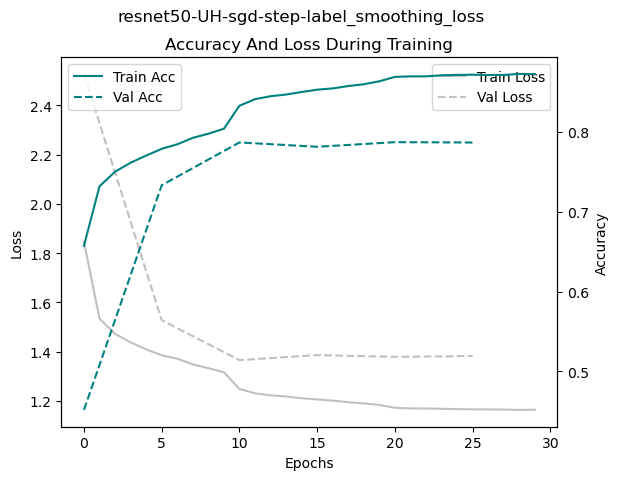

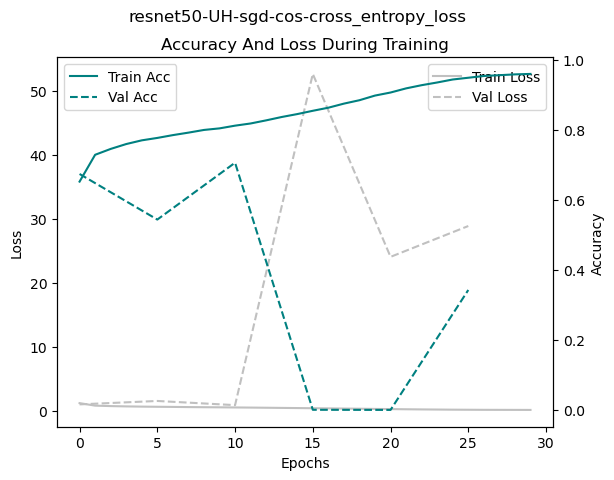

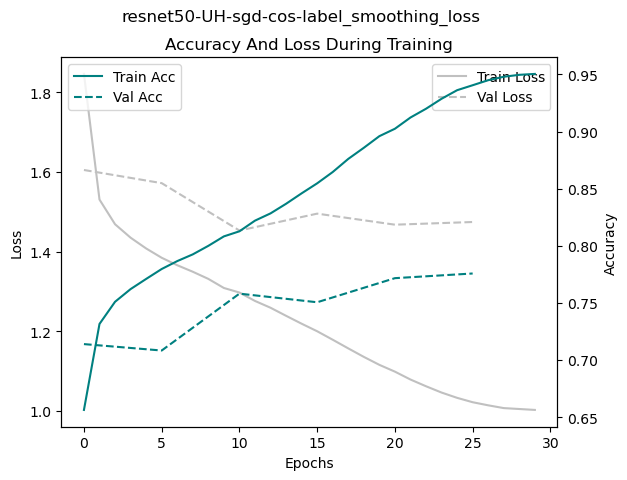

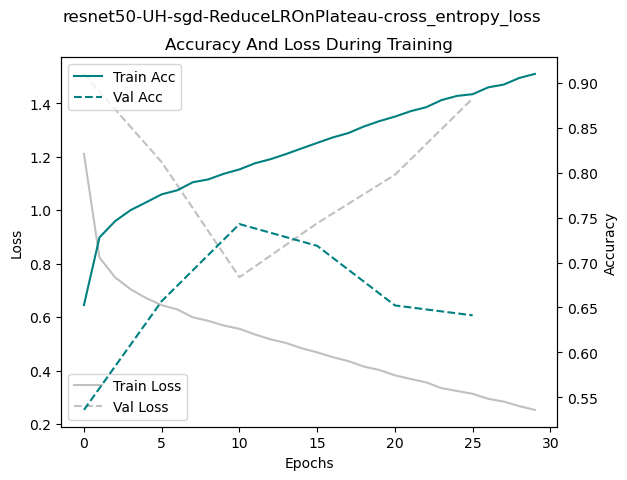

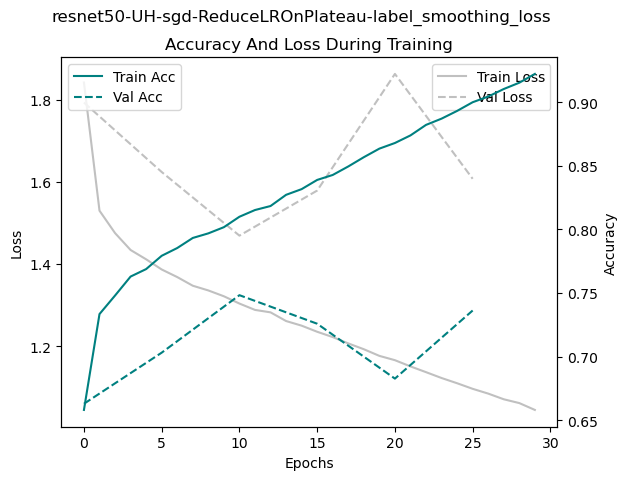

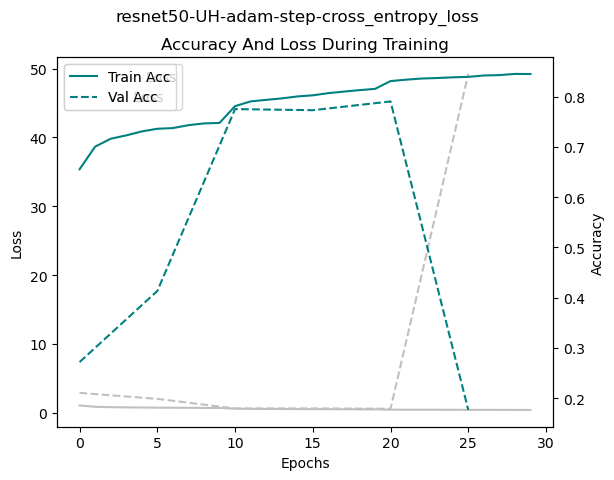

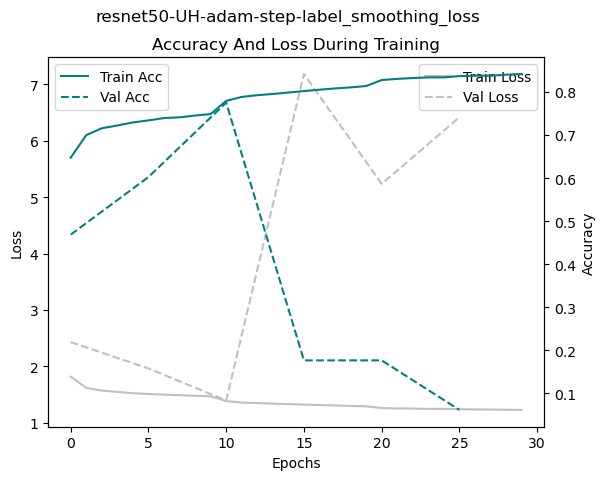

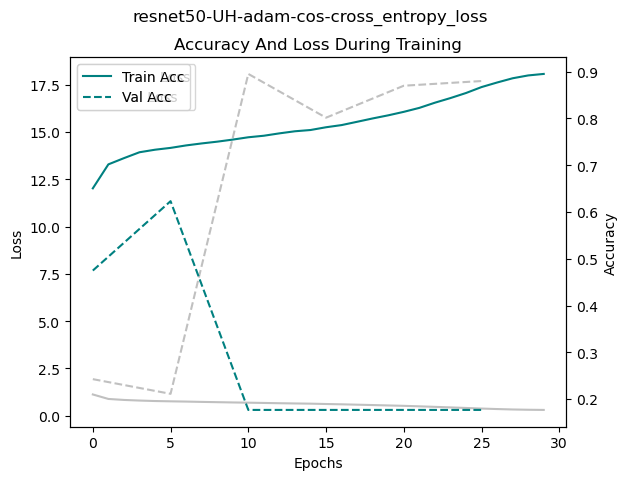

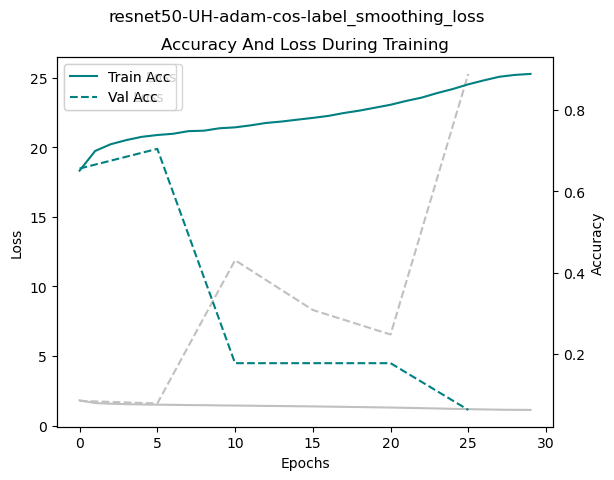

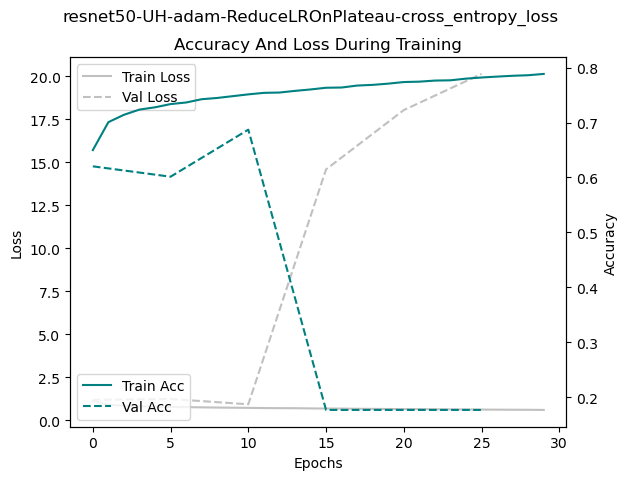

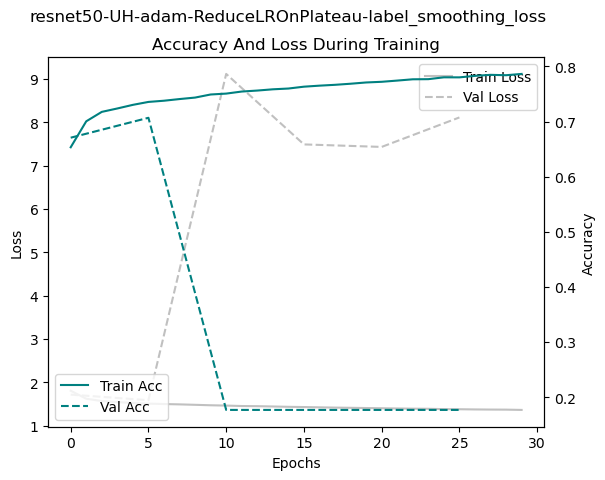

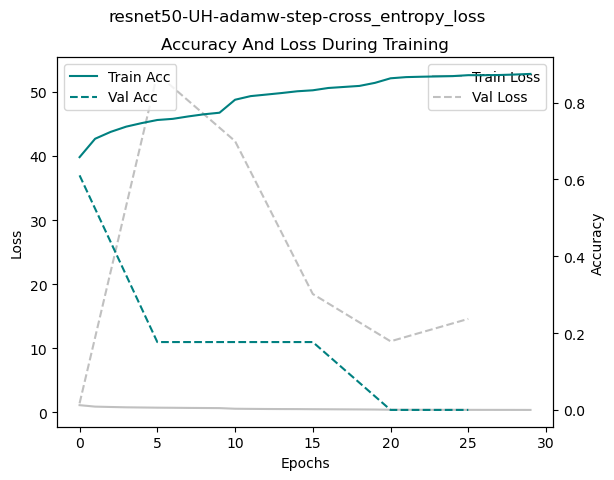

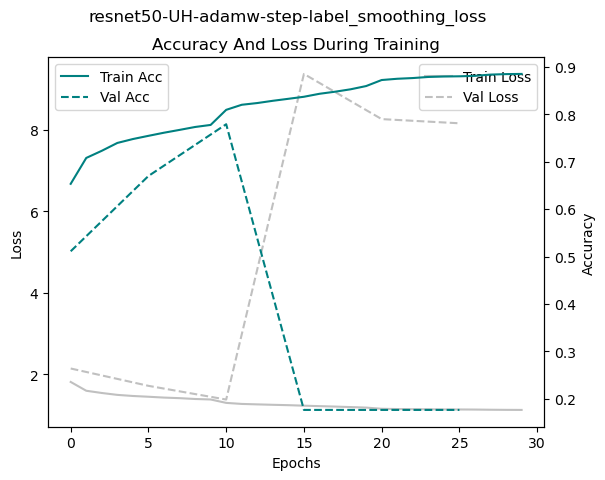

In [8]:
# Plot Accuracy and Loss
for i in range(len(df)):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  fig, ax = plt.subplots()
  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax.legend()
  plt.suptitle(f"{model_name}")
  plt.show()

# Model Comparison Plots

## Accuracy of models

In [9]:
df[['model_name', 'per_image_accuracy']].sort_values(by='per_image_accuracy', ascending=False)

,model_name,per_image_accuracy
1,resnet50-UH-sgd-step-label_smoothing_loss,0.788267
3,resnet50-UH-sgd-cos-label_smoothing_loss,0.777394
4,resnet50-UH-sgd-ReduceLROnPlateau-cross_entrop...,0.740388
5,resnet50-UH-sgd-ReduceLROnPlateau-label_smooth...,0.725490
0,resnet50-UH-sgd-step-cross_entropy_loss,0.342605
2,resnet50-UH-sgd-cos-cross_entropy_loss,0.176829
6,resnet50-UH-adam-step-cross_entropy_loss,0.176829
8,resnet50-UH-adam-cos-cross_entropy_loss,0.176829
11,resnet50-UH-adam-ReduceLROnPlateau-label_smoot...,0.176829
13,resnet50-UH-adamw-step-label_smoothing_loss,0.176829


## Per-Image vs Per-Class

/var/folders/3d/888v68391rv_kgq9_5s8b2x80000gn/T/ipykernel_85089/1324432173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


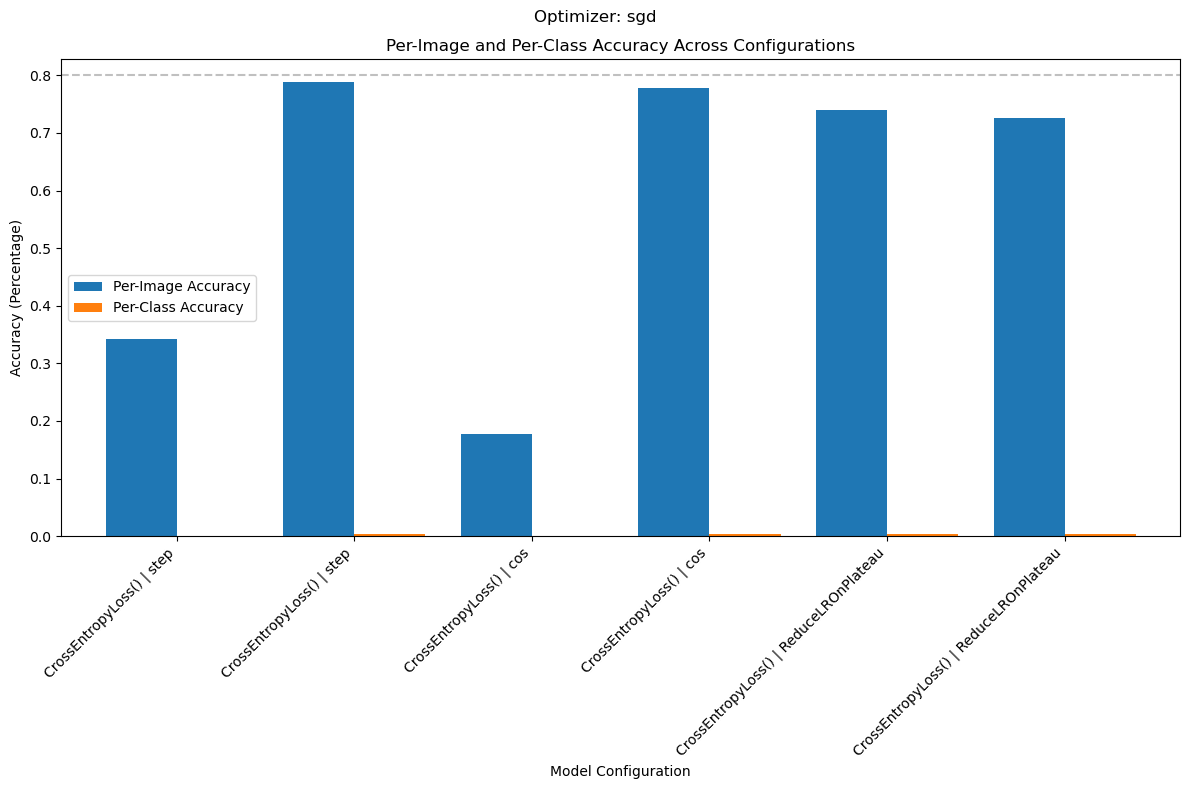

/var/folders/3d/888v68391rv_kgq9_5s8b2x80000gn/T/ipykernel_85089/1324432173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


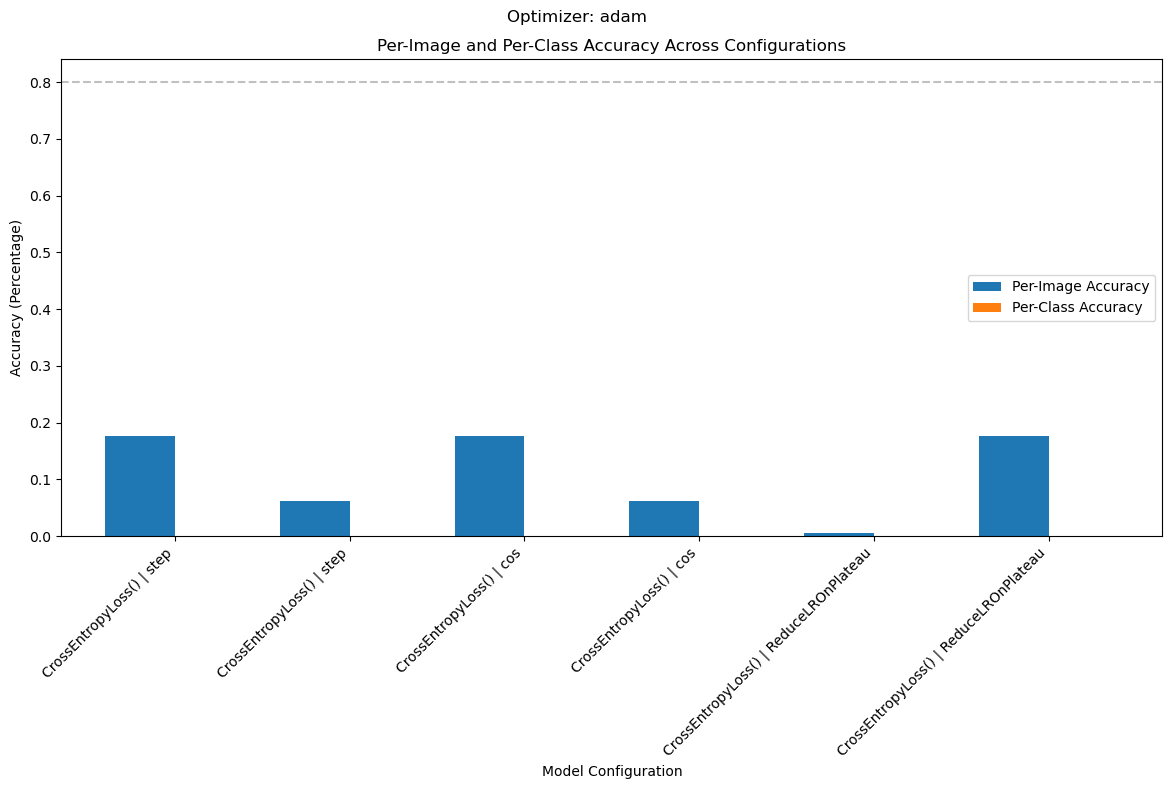

/var/folders/3d/888v68391rv_kgq9_5s8b2x80000gn/T/ipykernel_85089/1324432173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


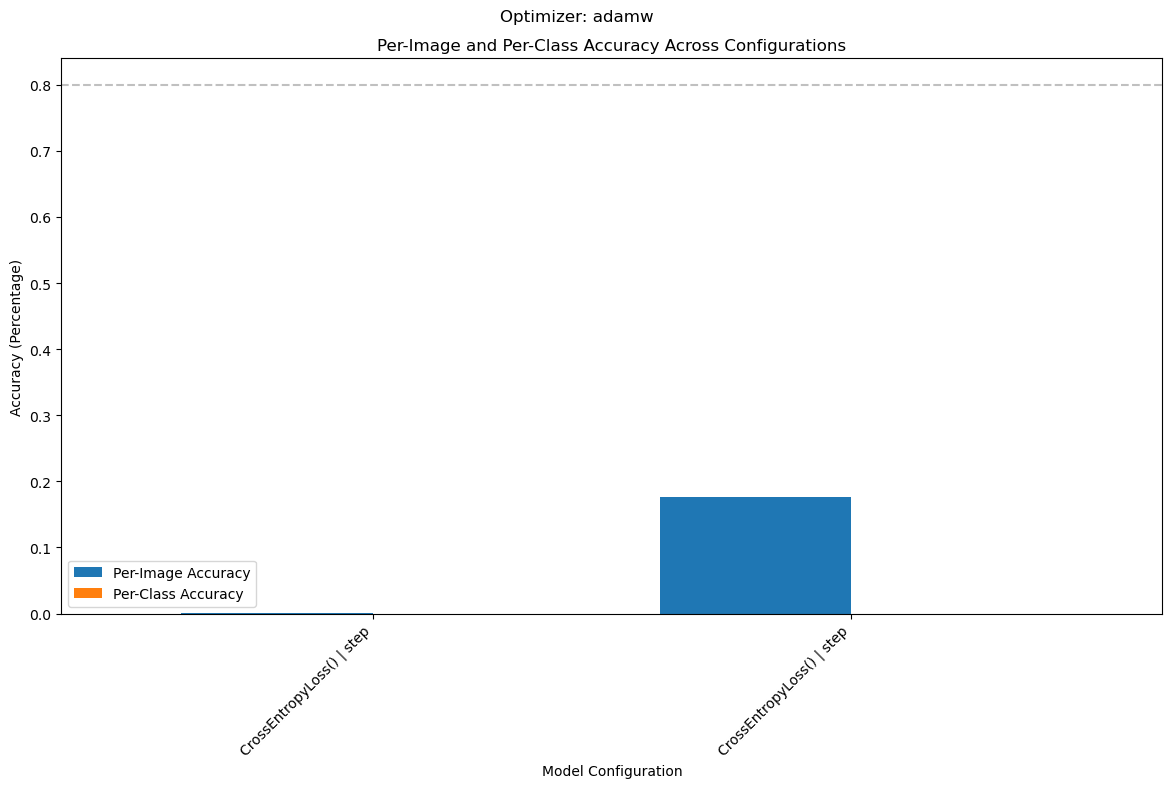

In [10]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','per_image_accuracy', 'per_class_accuracy']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Per-Image and Per-Class Accuracy Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("Accuracy (Percentage)")
  plt.xticks(rotation=45, ha="right")
  plt.legend(["Per-Image Accuracy", "Per-Class Accuracy"])
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()


## Wall Time

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


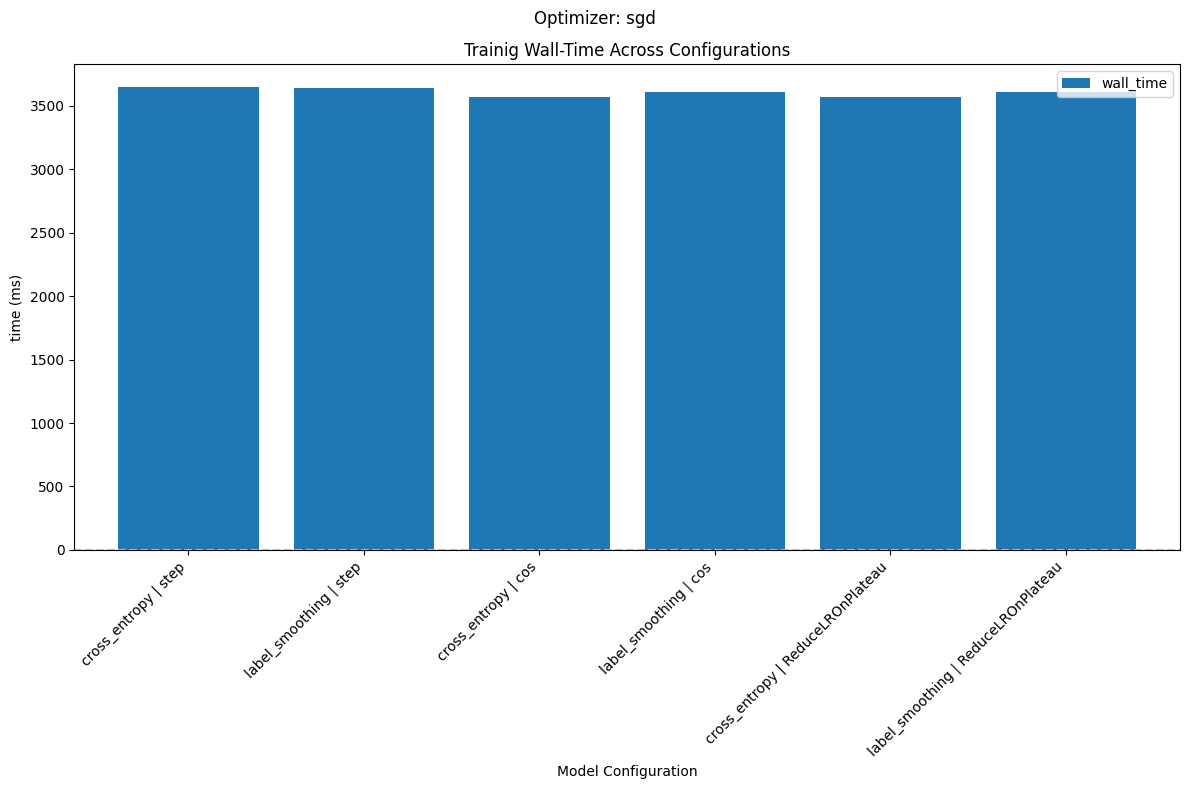

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


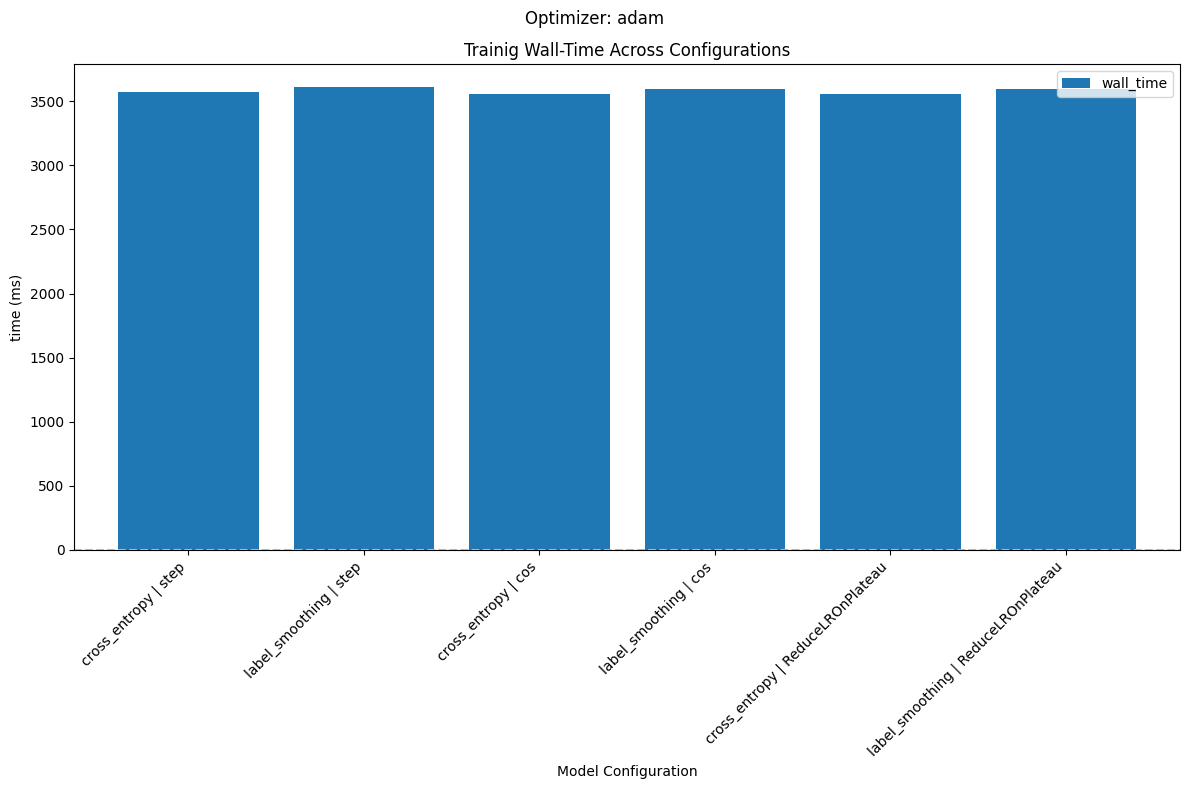

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


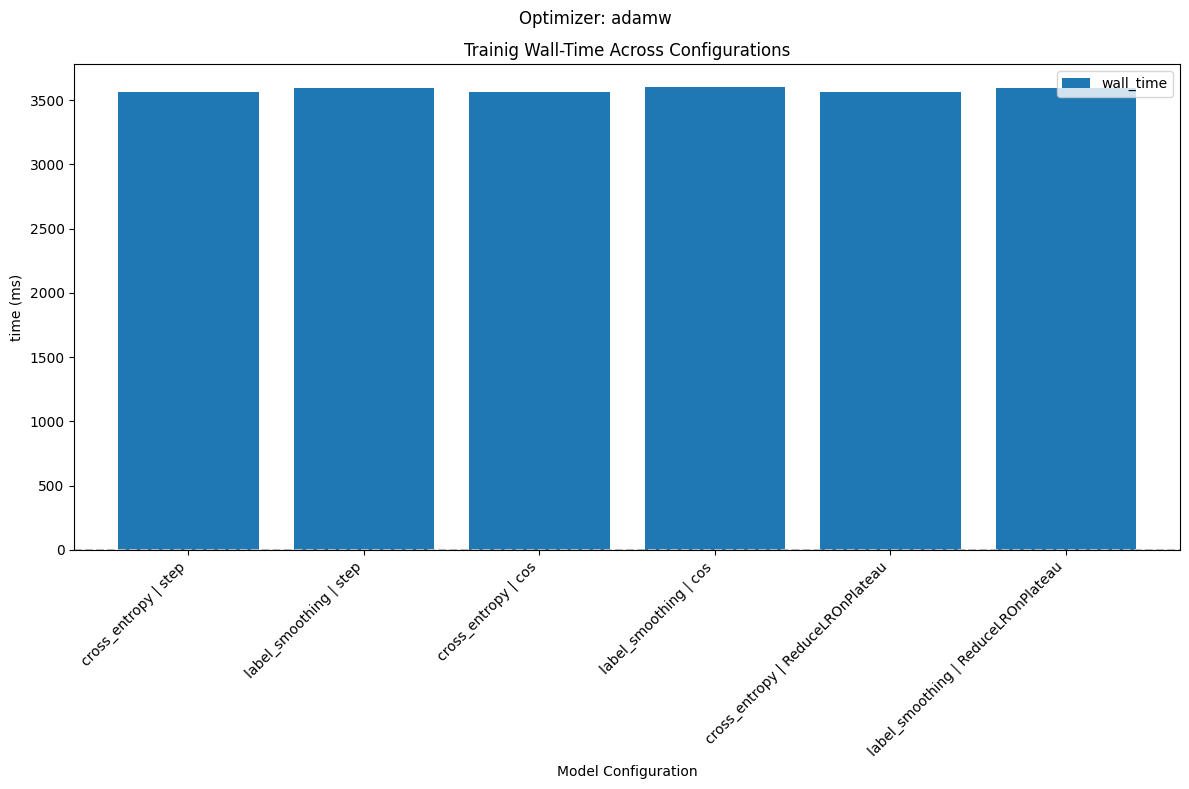

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','wall_time']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Trainig Wall-Time Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("time (ms)")
  plt.xticks(rotation=45, ha="right")
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()